# Competitive-binding Kd models

This notebook demonstrates competitive-binding models: `comp_3st_specific`, `comp_3st_total`, `comp_4st_specific`, and `comp_4st_total`.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

## Helper for synthetic competition data

In [37]:
data_all = bc.DoseResponseData.from_csv(
    "tutorial_data/synthetic/competitive_binding_wide.csv", 
    format="wide",
)

## Three-state specific competition

In [38]:
data_3st = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
results_3st = bc.fit(
    data_3st,
    model='comp_3st_specific',
    fixed={'RT': 0.01, 'LsT': 0.005, 'Kds': 0.5},
)
results_3st.summary()

,compound_id,N_exp,N_obs,ymin,ymin_SD,ymin_SEM,ymin_CI95_lower,ymin_CI95_upper,ymax,ymax_SD,...,Kds_CI95_upper,Kd,Kd_SD_lower,Kd_SD_upper,Kd_SEM_lower,Kd_SEM_upper,Kd_CI95_lower,Kd_CI95_upper,R_squared,Chi_squared
0,cmpd_1,3,33,1.050616,0.354116,0.204449,0.170942,1.930289,5034.832531,22.404681,...,0.5,0.014214,0.012697,0.015913,0.013317,0.015172,0.010738,0.018816,0.998689,73.292356


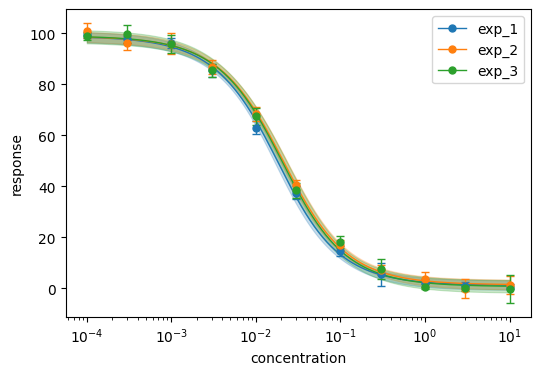

In [39]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_fits(data_3st, results_3st, ax=ax, confidence_band=True)
ax.set_xlabel("concentration")
ax.set_ylabel("response")
ax.legend()
plt.show()

## Three-state total competition

The total/nonspecific model uses dimensionless `N`.

In [40]:
data_3st_total = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
results_3st_total = bc.fit(
    data_3st_total,
    model='comp_3st_total',
    fixed={'RT': 0.01, 'LsT': 0.005, 'Kds': 0.02, 'N': 0.35},
)
results_3st_total.summary()

,compound_id,N_exp,N_obs,ymin,ymin_SD,ymin_SEM,ymin_CI95_lower,ymin_CI95_upper,ymax,ymax_SD,...,N_CI95_upper,Kd,Kd_SD_lower,Kd_SD_upper,Kd_SEM_lower,Kd_SEM_upper,Kd_CI95_lower,Kd_CI95_upper,R_squared,Chi_squared
0,cmpd_1,3,33,1.12941,0.355196,0.205072,0.247055,2.011765,327.180854,1.155813,...,0.35,0.00636,0.005667,0.007138,0.00595,0.006798,0.004775,0.008472,0.998333,93.213703


## Four-state specific competition

The four-state model adds `Kd3`, the affinity of labeled ligand to the receptor-competitor complex.

In [41]:
data_4st = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
results_4st = bc.fit(
    data_4st,
    model='comp_4st_specific',
    fixed={'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02, 'Kd3': 0.5},
)
results_4st.summary()

,compound_id,N_exp,N_obs,ymin,ymin_SD,ymin_SEM,ymin_CI95_lower,ymin_CI95_upper,ymax,ymax_SD,...,Kd3_CI95_upper,Kd,Kd_SD_lower,Kd_SD_upper,Kd_SEM_lower,Kd_SEM_upper,Kd_CI95_lower,Kd_CI95_upper,R_squared,Chi_squared
0,cmpd_1,3,33,-27.529218,2.578495,1.488695,-33.934554,-21.123882,158.562241,23.029151,...,0.5,0.03118,0.021125,0.046021,0.024904,0.039038,0.011854,0.082013,0.755568,13639.426729


## IC50-to-Kd conversion

Conversion is separate from fitting.

In [42]:
bc.convert_ic50_to_kd(
    model='cheng_prusoff',
    IC50=10.0,
    LsT=0.005,
    Kds=0.02,
)

IC50ConversionResult(compound_id=None, model='cheng_prusoff', IC50=10.0, Kd=8.0, lower_IC50=None, upper_IC50=None, lower_Kd=None, upper_Kd=None)